# 1. U.S. 30-Year Mortgage Rate (1976-06 to 2007-03)

Monthly data from `m-mortg.txt` (St. Louis Fed). Analysis: natural log of the rate, stationarity check, ARIMA identification and estimation, residual **Ljung–Box Q(12)** with df adjustment, model choice (AIC/BIC), and **1–4 step-ahead forecasts** from March 2007. All tests use **α = 5%**.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".matplotlib_cache"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams["figure.figsize"] = (10, 3)

data = pd.read_csv(
    "m-mortg.txt", sep=r"\s+", header=None,
    names=["year", "month", "day", "rate"],
)
data["date"] = pd.to_datetime(data[["year", "month", "day"]])
data = data.set_index("date").asfreq("MS")
data["log_rate"] = np.log(data["rate"])
y, dy = data["log_rate"], data["log_rate"].diff().dropna()


**Descriptive statistics, plots, and stationarity.** Summary table; time series of rate, log rate, and first difference of log rate; Augmented Dickey–Fuller on log level and on Δlog.

,rate,log_rate
count,370.000000,370.000000
mean,9.410838,2.197378
var,8.642994,0.086202
std,2.939897,0.293602
min,5.230000,1.654411
max,18.450000,2.915064


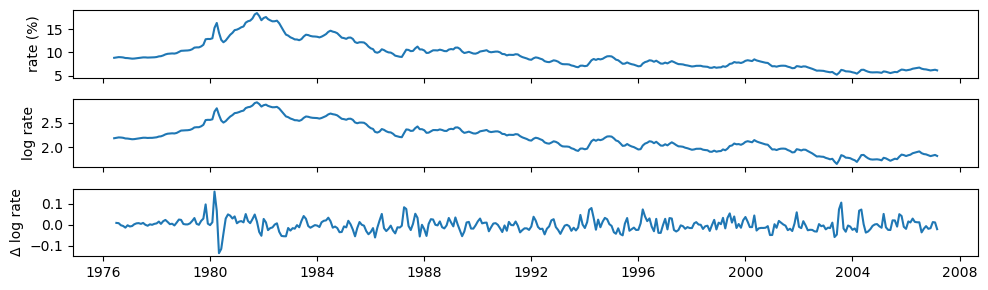

ADF log level: (np.float64(-0.7981520686389281), np.float64(0.8196642809000326))
ADF Δlog:      (np.float64(-10.518028000494931), np.float64(9.847402183085172e-19))


In [2]:
display(data[["rate", "log_rate"]].agg(["count", "mean", "var", "std", "min", "max"]))

fig, ax = plt.subplots(3, 1, sharex=True)
ax[0].plot(data.index, data["rate"])
ax[0].set_ylabel("rate (%)")
ax[1].plot(data.index, y)
ax[1].set_ylabel("log rate")
ax[2].plot(dy.index, dy)
ax[2].set_ylabel("Δ log rate")
plt.tight_layout()
plt.show()

print("ADF log level:", adfuller(y)[:2])
print("ADF Δlog:     ", adfuller(dy)[:2])


**Identification and estimation.** ACF/PACF of Δlog rate; Ljung–Box on Δlog at lag 12 (identification, no df adjustment). Fit ARIMA(p,1,q) for small orders; keep candidates with residual Q(12) p-value > 0.05; choose minimum AIC among them.

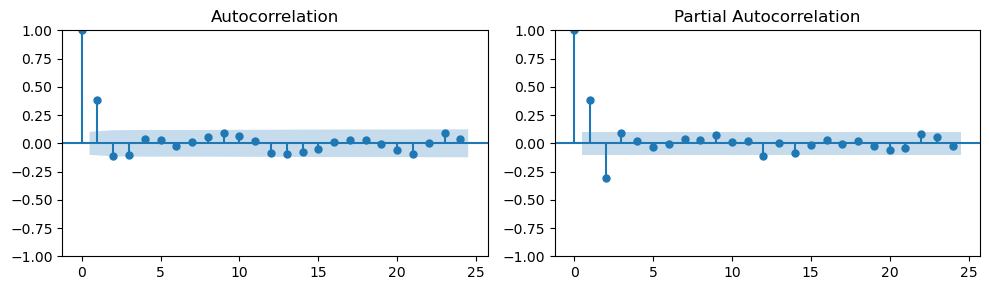

Ljung–Box Q(12) on Δlog (identification):
      lb_stat     lb_pvalue
12  74.503166  4.560687e-11


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Best order (lowest AIC with residual Q12 p>0.05): (3, 1, 0)
    order          AIC          BIC  Q12_p
(3, 1, 0) -1633.452882 -1617.809695    1.0
(0, 1, 3) -1632.850168 -1617.206981    1.0
(2, 1, 1) -1632.845486 -1617.202300    1.0
(2, 1, 0) -1632.523767 -1620.791377    1.0
(2, 1, 2) -1631.994499 -1612.440516    1.0
                               SARIMAX Results                                
Dep. Variable:               log_rate   No. Observations:                  370
Model:                 ARIMA(3, 1, 0)   Log Likelihood                 820.726
Date:                Thu, 09 Apr 2026   AIC                          -1633.453
Time:                        11:59:17   BIC                          -1617.810
Sample:                    06-01-1976   HQIC                         -1627.239
                         - 03-01-2007                                         
Covariance Type:                  opg                                         
                 coef    std err          z      

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(dy, lags=24, ax=axes[0])
plot_pacf(dy, lags=24, ax=axes[1], method="ywm")
plt.tight_layout()
plt.show()

print("Ljung–Box Q(12) on Δlog (identification):")
print(acorr_ljungbox(dy, lags=[12], return_df=True))

cand = []
for p in range(0, 5):
    for q in range(0, 5):
        if p == 0 and q == 0:
            continue
        try:
            res = ARIMA(y, order=(p, 1, q), trend="n").fit()
            lb = acorr_ljungbox(res.resid.dropna(), lags=[12], return_df=True)
            cand.append({
                "order": (p, 1, q),
                "AIC": res.aic,
                "BIC": res.bic,
                "Q12_p": float(lb["lb_pvalue"].iloc[0]),
            })
        except Exception:
            pass

cand_df = pd.DataFrame(cand).sort_values("AIC")
accepted = cand_df[cand_df["Q12_p"] > 0.05]
best_order = tuple(accepted.iloc[0]["order"])
print("\nBest order (lowest AIC with residual Q12 p>0.05):", best_order)
print(accepted.head(5).to_string(index=False))

final_model = ARIMA(y, order=best_order, trend="n").fit()
print(final_model.summary())


**Diagnostics, fitted equation, and forecasts.** Residual Ljung–Box Q(12) with **model_df = p + q**. Then 1–4 step forecasts (log and level); forecast origin is the last observation, March 2007.

In [4]:
p, d, q = best_order
lb_res = acorr_ljungbox(
    final_model.resid.dropna(), lags=[12], model_df=p + q, return_df=True
)
print("Residual Q(12) (df adjusted):\n", lb_res)

params = final_model.params
phi = [params.get(f"ar.L{i}", 0.0) for i in range(1, p + 1)]
print("\nFitted ARIMA(%d,1,%d) for y_t = log(r_t):" % (p, q))
print("(1 - %s)(1-B) y_t = a_t" % " - ".join(f"({phi[i]:.6f})B^{i+1}" for i in range(len(phi))))
print(params)

fc = final_model.get_forecast(steps=4)
out = pd.DataFrame({
    "forecast_log": fc.predicted_mean,
    "forecast_rate_%": np.exp(fc.predicted_mean),
})
out[["lo95_rate_%", "hi95_rate_%"]] = np.exp(fc.conf_int())
out


Residual Q(12) (df adjusted):
     lb_stat  lb_pvalue
12  0.05655        1.0

Fitted ARIMA(3,1,0) for y_t = log(r_t):
(1 - (0.532321)B^1 - (-0.349091)B^2 - (0.089383)B^3)(1-B) y_t = a_t
ar.L1     0.532321
ar.L2    -0.349091
ar.L3     0.089383
sigma2    0.000684
dtype: float64


,forecast_log,forecast_rate_%,lo95_rate_%,hi95_rate_%
2007-04-01,1.804210,6.075170,5.771567,6.394744
2007-05-01,1.805119,6.080696,5.536233,6.678705
2007-06-01,1.808577,6.101760,5.410594,6.881218
2007-07-01,1.808861,6.103493,5.314942,7.009037


**Conclusion:** Log rate is non-stationary; Δlog is stationary (ADF). **ARIMA(3,1,0)** on log rate is selected by AIC among specifications with white-noise residuals at lag 12; adjusted residual Q(12) is not significant at 5%. The table above gives Apr–Jul 2007 forecasts in percent.